In [1]:
# ============================================================
# 1: Imports and setup
# ============================================================

import sys
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns


# Add the current directory (ml/) to path
current_dir = Path.cwd().resolve()
ml_dir = current_dir if current_dir.name == 'ml' else current_dir.parent

# Add both ml and article_4 to path
article_4_dir = ml_dir / 'article_4'

sys.path.insert(0, str(ml_dir))
sys.path.insert(0, str(article_4_dir))

print(f"ML directory: {ml_dir}")
print(f"Article_4 directory: {article_4_dir}")
print(f"Current working dir: {Path.cwd()}")

# Import dataset modules
from article_4.datasets.dataset_loader import (
    load_all_datasets,
    split_features_targets,
)
from article_4.datasets.preprocessing import (
    prepare_training_data,
    save_preprocessor,
    get_feature_names,
)

# Import from models (core classes)
from article_4.models.xgboost_model import is_gpu_available

# Import from model configuration
from article_4.models.model_config import (
    DEFAULT_CONTROL_BOUNDS,
    LIGHT_SEARCH_SPACE,
    REDUCED_SEARCH_SPACE,
    DEFAULT_SEARCH_SPACE
)

# Import from training modules
from article_4.training.hyperparameter_search import GPUGridSearch
from article_4.training.train_xgboost import train_from_best_params

# Import from export modules
from article_4.export.export_xgboost import export_models_to_onnx
from article_4.export.verify_export import verify_dual_export

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("\n✅ All imports successful!")

# Verify
print(f"\n📦 Module verification:")
print(f"  load_all_datasets: {load_all_datasets.__module__}")
print(f"  is_gpu_available: {is_gpu_available.__module__}")
print(f"  GPUGridSearch: {GPUGridSearch.__module__}")
print(f"  DEFAULT_SEARCH_SPACE: {type(DEFAULT_SEARCH_SPACE)}")

ML directory: /home/aleksei/Projects/spatio_temporal_stream_processing/ml
Article_4 directory: /home/aleksei/Projects/spatio_temporal_stream_processing/ml/article_4
Current working dir: /home/aleksei/Projects/spatio_temporal_stream_processing/ml/notebooks

✅ All imports successful!

📦 Module verification:
  load_all_datasets: article_4.datasets.dataset_loader
  is_gpu_available: article_4.models.xgboost_model
  GPUGridSearch: article_4.training.hyperparameter_search
  DEFAULT_SEARCH_SPACE: <class 'article_4.models.model_config.HyperparameterSearchSpace'>


In [2]:
# ============================================================
# 2: Check GPU availability
# ============================================================

print("="*60)
print("GPU Availability Check")
print("="*60)

gpu_available = is_gpu_available()
if gpu_available:
    print("✅ GPU ACCELERATION AVAILABLE")
    print("   Hyperparameter tuning will be 10-20x faster!")
else:
    print("⚠️  GPU not available - using CPU")
    print("   Tuning will be slower but still works")

GPU Availability Check
✅ GPU detected and working with XGBoost 3.2.0+
✅ GPU ACCELERATION AVAILABLE
   Hyperparameter tuning will be 10-20x faster!


In [3]:
# ============================================================
# 3: Load datasets
# ============================================================

def find_project_root():
    current = Path.cwd()
    for parent in [current] + list(current.parents):
        if (parent / "data").exists() and (parent / "ml").exists():
            return parent
    return Path.home() / "Projects" / "spatio_temporal_stream_processing"

ROOT = find_project_root()
print(f"Project root: {ROOT}")

# Import and configure dataset loader
from article_4.datasets import dataset_loader

dataset_loader.DATA_ROOT = ROOT / "data" / "article_4"
dataset_loader.TRAIN_PATH = dataset_loader.DATA_ROOT / "training" / "train.csv"
dataset_loader.VALIDATION_PATH = dataset_loader.DATA_ROOT / "validation" / "validation.csv"
dataset_loader.TEST_PATH = dataset_loader.DATA_ROOT / "test" / "test.csv"

print(f"\nDataset paths:")
print(f"  Train: {dataset_loader.TRAIN_PATH}")
print(f"  Validation: {dataset_loader.VALIDATION_PATH}")
print(f"  Test: {dataset_loader.TEST_PATH}")

# Load datasets
print("\n" + "="*60)
print("Loading Datasets")
print("="*60)

try:
    train_df, validation_df, test_df = dataset_loader.load_all_datasets()
    
    print(f"✅ Training dataset:     {train_df.shape}")
    print(f"✅ Validation dataset:   {validation_df.shape}")
    print(f"✅ Test dataset:         {test_df.shape}")
    
    print("\nTraining data preview:")
    display(train_df.head())
    
    print("\nMissing values:")
    print(f"  Training: {train_df.isnull().sum().sum()}")
    print(f"  Validation: {validation_df.isnull().sum().sum()}")
    print(f"  Test: {test_df.isnull().sum().sum()}")
    
except FileNotFoundError as e:
    print(f"\n❌ Error: {e}")
    print("Please generate dataset first using parser scripts")


Project root: /home/aleksei/Projects/spatio_temporal_stream_processing

Dataset paths:
  Train: /home/aleksei/Projects/spatio_temporal_stream_processing/data/article_4/training/train.csv
  Validation: /home/aleksei/Projects/spatio_temporal_stream_processing/data/article_4/validation/validation.csv
  Test: /home/aleksei/Projects/spatio_temporal_stream_processing/data/article_4/test/test.csv

Loading Datasets
✅ Training dataset:     (2780, 26)
✅ Validation dataset:   (596, 26)
✅ Test dataset:         (596, 26)

Training data preview:


,profile,rate_pattern,motion_mode,window_size_ms,watermark_delay_ms,run_timestamp,event_rate,disorder_ratio,late_event_ratio,avg_latency_ms,...,watermark_lag_ms,processing_latency_ms,adaptive_window_ms,adaptive_watermark_ms,collision_count,proximity_count,swarm_count,conflict_count,total_events,total_interactions
0,late,constant,straight,3000,5000,20260604_000356,55.0,0.8156,0.0000,6371.07,...,0,4848,3000,5000,0,0,0,0,10697,0
1,mixed,burst,collision,5000,5000,20260604_223617,68.8,0.9566,0.0079,7268.92,...,0,3226,5000,5000,1063,3116,180,713,24020,5072
2,late,burst,random_walk,5000,5000,20260604_001620,85.0,0.8661,0.0045,8365.96,...,0,7026,5000,5000,0,0,0,0,33150,0
3,realtime,constant,straight,1000,500,20260603_203825,47.6,0.0007,0.0569,1142.06,...,0,659,1000,500,0,0,0,0,8960,0
4,realtime,constant,straight,1000,500,20260603_203825,47.6,0.0006,0.0571,1140.31,...,0,624,1000,500,0,0,0,0,10768,0



Missing values:
  Training: 0
  Validation: 0
  Test: 0


In [4]:
# ============================================================
# 4: Split features and targets
# ============================================================

print("\n" + "="*60)
print("Splitting Features and Targets")
print("="*60)

X_train, y_train = split_features_targets(train_df)
X_val, y_val = split_features_targets(validation_df)
X_test, y_test = split_features_targets(test_df)

# Extract individual targets
y_train_window = y_train['adaptive_window_ms'].values
y_train_watermark = y_train['adaptive_watermark_ms'].values

y_val_window = y_val['adaptive_window_ms'].values
y_val_watermark = y_val['adaptive_watermark_ms'].values

y_test_window = y_test['adaptive_window_ms'].values
y_test_watermark = y_test['adaptive_watermark_ms'].values

print(f"X_train shape: {X_train.shape}")
print(f"y_train_window shape: {y_train_window.shape}")
print(f"y_train_watermark shape: {y_train_watermark.shape}")
print(f"\nX_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")

print("\nTarget Statistics:")
print(
    f"Window - Min: {y_train_window.min():.0f}, "
    f"Max: {y_train_window.max():.0f}, Mean: {y_train_window.mean():.0f}"
)
print(
    f"Watermark - Min: {y_train_watermark.min():.0f}, "
    f"Max: {y_train_watermark.max():.0f}, Mean: {y_train_watermark.mean():.0f}"
)


Splitting Features and Targets
X_train shape: (2780, 15)
y_train_window shape: (2780,)
y_train_watermark shape: (2780,)

X_val shape: (596, 15)
X_test shape: (596, 15)

Target Statistics:
Window - Min: 1000, Max: 10000, Mean: 3049
Watermark - Min: 500, Max: 5000, Mean: 3121


In [5]:
# ============================================================
# 5: Preprocess features
# ============================================================

print("\n" + "="*60)
print("Preprocessing Features")
print("="*60)

X_train_processed, X_val_processed, X_test_processed, preprocessor = prepare_training_data(
    X_train, X_val, X_test
)

feature_names = get_feature_names(preprocessor)

print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"X_val_processed shape: {X_val_processed.shape}")
print(f"X_test_processed shape: {X_test_processed.shape}")
print(f"Number of features after preprocessing: {len(feature_names)}")

save_preprocessor(preprocessor)
print("✅ Preprocessor saved")


Preprocessing Features
X_train_processed shape: (2780, 25)
X_val_processed shape: (596, 25)
X_test_processed shape: (596, 25)
Number of features after preprocessing: 25
✅ Preprocessor saved


In [6]:
# ============================================================
# 6: Hyperparameter Tuning (GPU Accelerated)
# ============================================================

print("\n" + "="*60)
print("Hyperparameter Tuning on RTX 4070 Super")
print("="*60)

# Choose search mode: "light", "reduced", or "full"
SEARCH_MODE = "reduced"  # Change to "light" for quick test, "reduced" for final tuning

# Import search spaces
from article_4.models.model_config import (
    LIGHT_SEARCH_SPACE,
    REDUCED_SEARCH_SPACE,
    DEFAULT_SEARCH_SPACE
)

# Create tuner with GPU acceleration
tuner = GPUGridSearch(
    X_train_processed,
    y_train_window,
    y_train_watermark,
    X_val_processed,
    y_val_window,
    y_val_watermark,
    use_gpu=True,
    verbose=True,
)

# Select parameter grid based on SEARCH_MODE
if SEARCH_MODE == "light":
    param_grid = LIGHT_SEARCH_SPACE.to_dict()
    total_combinations = (
        len(LIGHT_SEARCH_SPACE.n_estimators) *
        len(LIGHT_SEARCH_SPACE.max_depth) *
        len(LIGHT_SEARCH_SPACE.learning_rate) *
        len(LIGHT_SEARCH_SPACE.min_child_weight) *
        len(LIGHT_SEARCH_SPACE.subsample) *
        len(LIGHT_SEARCH_SPACE.colsample_bytree) *
        len(LIGHT_SEARCH_SPACE.reg_alpha) *
        len(LIGHT_SEARCH_SPACE.reg_lambda)
    )
    print(f"\n🚀 Running LIGHT GRID SEARCH...")
    print(f"   Total combinations: {total_combinations}")
    print("   Estimated time: 3-4 seconds on RTX 4070 Super\n")
    
elif SEARCH_MODE == "reduced":
    param_grid = REDUCED_SEARCH_SPACE.to_dict()
    total_combinations = (
        len(REDUCED_SEARCH_SPACE.n_estimators) *
        len(REDUCED_SEARCH_SPACE.max_depth) *
        len(REDUCED_SEARCH_SPACE.learning_rate) *
        len(REDUCED_SEARCH_SPACE.min_child_weight) *
        len(REDUCED_SEARCH_SPACE.subsample) *
        len(REDUCED_SEARCH_SPACE.colsample_bytree) *
        len(REDUCED_SEARCH_SPACE.reg_alpha) *
        len(REDUCED_SEARCH_SPACE.reg_lambda)
    )
    print(f"\n🚀 Running REDUCED GRID SEARCH...")
    print(f"   Total combinations: {total_combinations}")
    print("   Estimated time: 90-120 seconds on RTX 4070 Super\n")
    
elif SEARCH_MODE == "full":
    param_grid = DEFAULT_SEARCH_SPACE.to_dict()
    total_combinations = (
        len(DEFAULT_SEARCH_SPACE.n_estimators) *
        len(DEFAULT_SEARCH_SPACE.max_depth) *
        len(DEFAULT_SEARCH_SPACE.learning_rate) *
        len(DEFAULT_SEARCH_SPACE.min_child_weight) *
        len(DEFAULT_SEARCH_SPACE.subsample) *
        len(DEFAULT_SEARCH_SPACE.colsample_bytree) *
        len(DEFAULT_SEARCH_SPACE.reg_alpha) *
        len(DEFAULT_SEARCH_SPACE.reg_lambda)
    )
    print(f"\n🚀 Running FULL GRID SEARCH...")
    print(f"   Total combinations: {total_combinations:,}")
    print("   ⚠️  WARNING: This will take ~13.5 days!\n")
    
else:
    raise ValueError(f"Invalid SEARCH_MODE: {SEARCH_MODE}. Use 'light', 'reduced', or 'full'")

# Search window model
print("📊 Searching WINDOW model...")
window_params, window_metrics = tuner.grid_search_window_model(
    param_grid=param_grid,
    n_iterations=None,
)

# Search watermark model
print("\n📊 Searching WATERMARK model...")
watermark_params, watermark_metrics = tuner.grid_search_watermark_model(
    param_grid=param_grid,
    n_iterations=None,
)

print("\n🏆 BEST PARAMETERS FOUND:")
print("\nWindow Model (adaptive_window_ms):")
for key, value in window_params.items():
    print(f"  {key}: {value}")
print(f"  Validation RMSE: {window_metrics['rmse']:.4f}")

print("\nWatermark Model (adaptive_watermark_ms):")
for key, value in watermark_params.items():
    print(f"  {key}: {value}")
print(f"  Validation RMSE: {watermark_metrics['rmse']:.4f}")


Hyperparameter Tuning on RTX 4070 Super
✅ GPU detected and working with XGBoost 3.2.0+
🚀 GPU ACCELERATION ENABLED

🚀 Running REDUCED GRID SEARCH...
   Total combinations: 864
   Estimated time: 90-120 seconds on RTX 4070 Super

📊 Searching WINDOW model...

🔍 Grid Search for Window Model
   Device: GPU
   Combinations: 864
   Estimated time: ~259.2s on GPU
------------------------------------------------------------
✅ GPU detected and working with XGBoost 3.2.0+
   ✨ New best RMSE: 42.1748 | Params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 100, 'reg_alpha': 0.05, 'reg_lambda': 0.5, 'subsample': 0.8}
✅ GPU detected and working with XGBoost 3.2.0+
   ✨ New best RMSE: 39.9662 | Params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 100, 'reg_alpha': 0.05, 'reg_lambda': 0.5, 'subsample': 0.9}
✅ GPU detected and working with XGBoost 3.2.0+
   ✨ New best RMSE: 39.2101 | Par

In [7]:
# ============================================================
# 7: Display best parameters
# ============================================================

print("\n" + "="*60)
print("🏆 BEST PARAMETERS FOUND")
print("="*60)

print("\n📊 Window Model (adaptive_window_ms):")
print("-" * 40)
for key, value in window_params.items():
    print(f"  {key:20s}: {value}")
print(f"  {'Validation RMSE':20s}: {window_metrics['rmse']:.4f}")
print(f"  {'Validation MAE':20s}: {window_metrics['mae']:.4f}")
print(f"  {'Validation R²':20s}: {window_metrics['r2']:.4f}")

print("\n📊 Watermark Model (adaptive_watermark_ms):")
print("-" * 40)
for key, value in watermark_params.items():
    print(f"  {key:20s}: {value}")
print(f"  {'Validation RMSE':20s}: {watermark_metrics['rmse']:.4f}")
print(f"  {'Validation MAE':20s}: {watermark_metrics['mae']:.4f}")
print(f"  {'Validation R²':20s}: {watermark_metrics['r2']:.4f}")


🏆 BEST PARAMETERS FOUND

📊 Window Model (adaptive_window_ms):
----------------------------------------
  colsample_bytree    : 0.9
  learning_rate       : 0.1
  max_depth           : 6
  min_child_weight    : 3
  n_estimators        : 150
  reg_alpha           : 0.05
  reg_lambda          : 1.0
  subsample           : 0.9
  Validation RMSE     : 11.9525
  Validation MAE      : 3.3677
  Validation R²       : 1.0000

📊 Watermark Model (adaptive_watermark_ms):
----------------------------------------
  colsample_bytree    : 0.8
  learning_rate       : 0.1
  max_depth           : 5
  min_child_weight    : 3
  n_estimators        : 100
  reg_alpha           : 0.1
  reg_lambda          : 0.5
  subsample           : 0.9
  Validation RMSE     : 14.3055
  Validation MAE      : 4.0547
  Validation R²       : 0.9999


In [8]:
# ============================================================
# 8: Train final models with best parameters
# ============================================================

print("\n" + "="*60)
print("Training Final Models with Best Parameters")
print("="*60)

models = train_from_best_params(
    X_train_processed,
    y_train_window,
    y_train_watermark,
    X_val_processed,
    y_val_window,
    y_val_watermark,
    window_params=window_params,
    watermark_params=watermark_params,
    feature_names=feature_names.tolist(),
    use_gpu=True,
    verbose=True,
)

print("\n✅ Final models trained!")


Training Final Models with Best Parameters
✅ GPU detected and working with XGBoost 3.2.0+
🚀 GPU ACCELERATION ENABLED
✅ GPU detected and working with XGBoost 3.2.0+
🚀 GPU ACCELERATION ENABLED
✅ GPU detected and working with XGBoost 3.2.0+
🚀 GPU ACCELERATION ENABLED
✅ GPU detected and working with XGBoost 3.2.0+
🚀 GPU ACCELERATION ENABLED

📊 Training Model_A_Window_Final on GPU
   Training samples: 2780
[0]	validation_0-rmse:2294.44681	validation_1-rmse:2155.50902
[1]	validation_0-rmse:2068.47836	validation_1-rmse:1941.46397
[2]	validation_0-rmse:1865.80315	validation_1-rmse:1748.80624
[3]	validation_0-rmse:1682.37522	validation_1-rmse:1574.97765
[4]	validation_0-rmse:1517.74012	validation_1-rmse:1419.98427
[5]	validation_0-rmse:1369.91014	validation_1-rmse:1279.00365
[6]	validation_0-rmse:1236.62265	validation_1-rmse:1152.98809
[7]	validation_0-rmse:1115.81675	validation_1-rmse:1038.69118
[8]	validation_0-rmse:1007.59469	validation_1-rmse:935.61133
[9]	validation_0-rmse:909.87085	valid

In [9]:
# ============================================================
# 9: Evaluate on test set
# ============================================================

print("\n" + "="*60)
print("Test Set Evaluation")
print("="*60)

test_metrics = models.evaluate(
    X_test_processed,
    y_test_window,
    y_test_watermark
)

print("\n📊 TEST SET RESULTS:")
print("-" * 40)
print("Window Model (adaptive_window_ms):")
print(f"  RMSE: {test_metrics['window_model']['rmse']:.2f} ms")
print(f"  MAE:  {test_metrics['window_model']['mae']:.2f} ms")
print(f"  R²:   {test_metrics['window_model']['r2']:.4f}")

print("\nWatermark Model (adaptive_watermark_ms):")
print(f"  RMSE: {test_metrics['watermark_model']['rmse']:.2f} ms")
print(f"  MAE:  {test_metrics['watermark_model']['mae']:.2f} ms")
print(f"  R²:   {test_metrics['watermark_model']['r2']:.4f}")

print(f"\nCombined RMSE: {test_metrics['combined_rmse']:.2f} ms")
print(f"\nTraining times: {test_metrics['training_times']}")
print(f"Devices used: {test_metrics['devices']}")


Test Set Evaluation

📊 TEST SET RESULTS:
----------------------------------------
Window Model (adaptive_window_ms):
  RMSE: 47.18 ms
  MAE:  7.19 ms
  R²:   0.9997

Watermark Model (adaptive_watermark_ms):
  RMSE: 29.38 ms
  MAE:  6.78 ms
  R²:   0.9996

Combined RMSE: 39.30 ms

Training times: {'window': 0.49006056785583496, 'watermark': 0.3097701072692871}
Devices used: {'window': 'gpu', 'watermark': 'gpu'}



Feature Importance Analysis


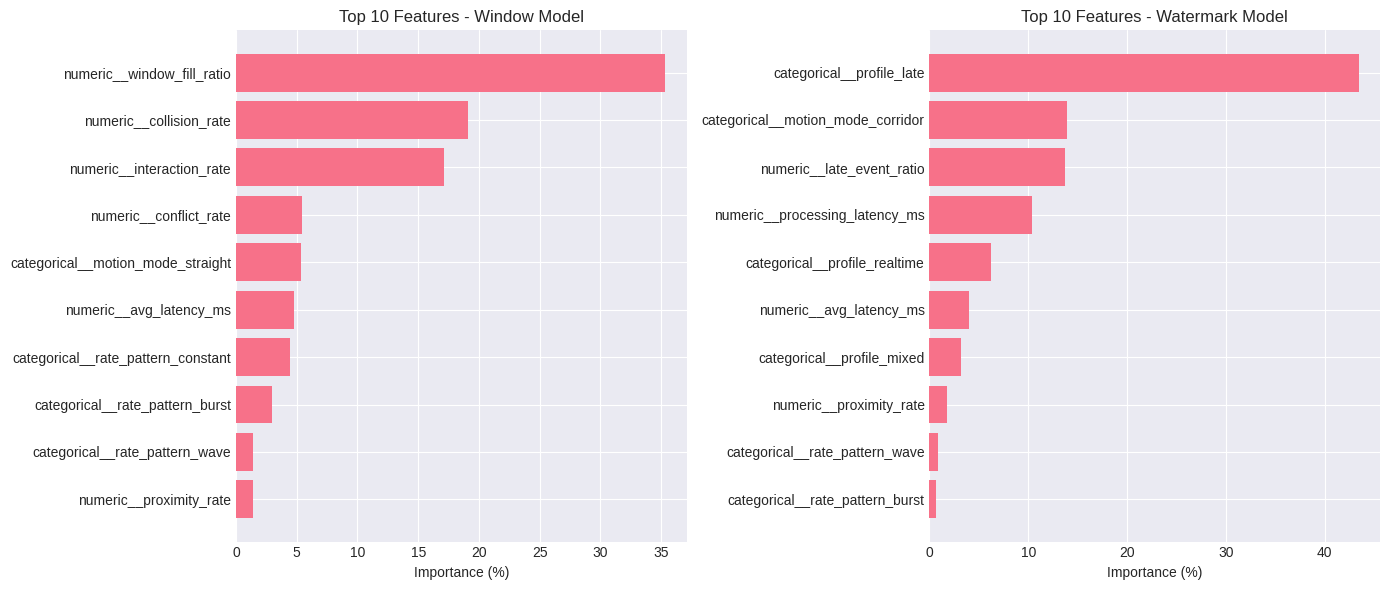


Window Model - Top 5 Features:
                          feature  importance  importance_percent
       numeric__window_fill_ratio    0.353179           35.317848
          numeric__collision_rate    0.190746           19.074587
        numeric__interaction_rate    0.171433           17.143297
           numeric__conflict_rate    0.054389            5.438852
categorical__motion_mode_straight    0.053332            5.333203

Watermark Model - Top 5 Features:
                          feature  importance  importance_percent
        categorical__profile_late    0.434282           43.428207
categorical__motion_mode_corridor    0.138838           13.883848
        numeric__late_event_ratio    0.137112           13.711180
   numeric__processing_latency_ms    0.103588           10.358785
    categorical__profile_realtime    0.062674            6.267408


In [10]:
# ============================================================
# 10: Feature importance analysis
# ============================================================

print("\n" + "="*60)
print("Feature Importance Analysis")
print("="*60)

window_importance = models.model_a.get_feature_importance()
watermark_importance = models.model_b.get_feature_importance()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

top_features_window = window_importance.head(10)
ax1.barh(range(len(top_features_window)), top_features_window['importance_percent'])
ax1.set_yticks(range(len(top_features_window)))
ax1.set_yticklabels(top_features_window['feature'])
ax1.set_xlabel('Importance (%)')
ax1.set_title('Top 10 Features - Window Model')
ax1.invert_yaxis()

top_features_watermark = watermark_importance.head(10)
ax2.barh(range(len(top_features_watermark)), top_features_watermark['importance_percent'])
ax2.set_yticks(range(len(top_features_watermark)))
ax2.set_yticklabels(top_features_watermark['feature'])
ax2.set_xlabel('Importance (%)')
ax2.set_title('Top 10 Features - Watermark Model')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

print("\nWindow Model - Top 5 Features:")
print(window_importance.head(5).to_string(index=False))
print("\nWatermark Model - Top 5 Features:")
print(watermark_importance.head(5).to_string(index=False))


Predictions vs Actual Analysis


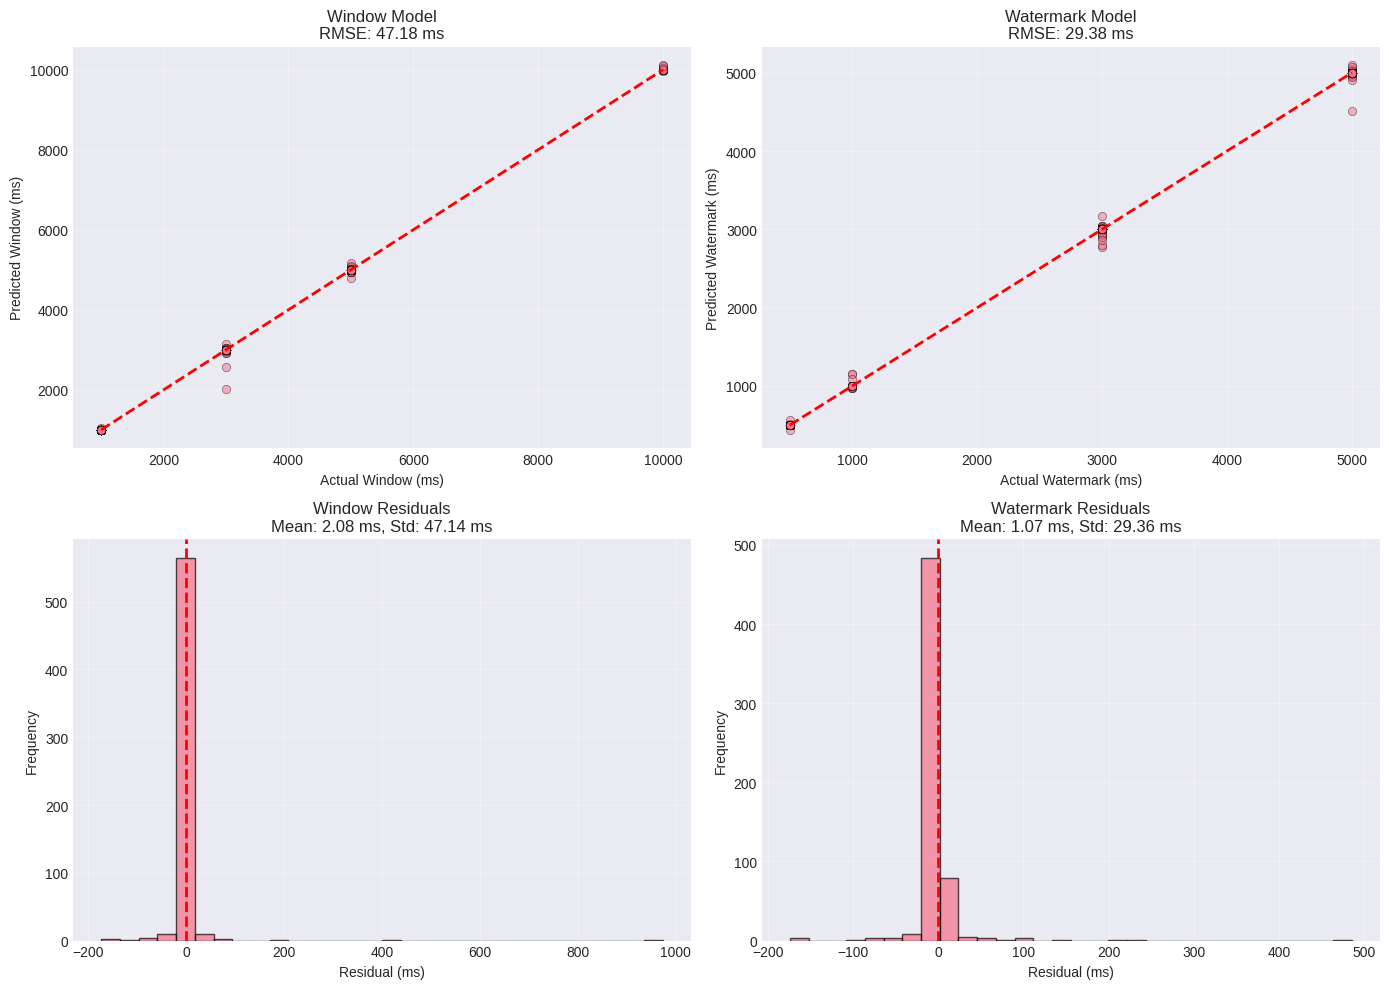

In [11]:
# ============================================================
# 11: Predictions vs Actual visualization
# ============================================================

print("\n" + "="*60)
print("Predictions vs Actual Analysis")
print("="*60)

window_pred, watermark_pred = models.predict(X_test_processed)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Window predictions scatter
axes[0, 0].scatter(y_test_window, window_pred, alpha=0.5, edgecolors='k', linewidth=0.5)
axes[0, 0].plot([y_test_window.min(), y_test_window.max()], 
                [y_test_window.min(), y_test_window.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual Window (ms)')
axes[0, 0].set_ylabel('Predicted Window (ms)')
axes[0, 0].set_title(f'Window Model\nRMSE: {test_metrics["window_model"]["rmse"]:.2f} ms')
axes[0, 0].grid(True, alpha=0.3)

# Watermark predictions scatter
axes[0, 1].scatter(y_test_watermark, watermark_pred, alpha=0.5, edgecolors='k', linewidth=0.5)
axes[0, 1].plot([y_test_watermark.min(), y_test_watermark.max()], 
                [y_test_watermark.min(), y_test_watermark.max()], 'r--', lw=2)
axes[0, 1].set_xlabel('Actual Watermark (ms)')
axes[0, 1].set_ylabel('Predicted Watermark (ms)')
axes[0, 1].set_title(f'Watermark Model\nRMSE: {test_metrics["watermark_model"]["rmse"]:.2f} ms')
axes[0, 1].grid(True, alpha=0.3)

# Window residuals
window_residuals = y_test_window - window_pred
axes[1, 0].hist(window_residuals, bins=30, edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Residual (ms)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title(f'Window Residuals\nMean: {window_residuals.mean():.2f} ms, Std: {window_residuals.std():.2f} ms')
axes[1, 0].grid(True, alpha=0.3)

# Watermark residuals
watermark_residuals = y_test_watermark - watermark_pred
axes[1, 1].hist(watermark_residuals, bins=30, edgecolor='black', alpha=0.7)
axes[1, 1].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Residual (ms)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title(f'Watermark Residuals\nMean: {watermark_residuals.mean():.2f} ms, Std: {watermark_residuals.std():.2f} ms')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# 12: Save models
# ============================================================

print("\n" + "="*60)
print("Saving Models")
print("="*60)

models.save()
print("✅ Models saved to disk")


Saving Models
   💾 Saved Model_A_Window_Final to /home/aleksei/Projects/spatio_temporal_stream_processing/ml/article_4/models/xgboost/model_a_window.joblib
   💾 Saved Model_B_Watermark_Final to /home/aleksei/Projects/spatio_temporal_stream_processing/ml/article_4/models/xgboost/model_b_watermark.joblib
✅ Models saved to disk


In [13]:
# ============================================================
# 13: Export to ONNX for Flink deployment
# ============================================================

print("\n" + "="*60)
print("Exporting to ONNX for Flink Deployment")
print("="*60)

window_onnx_path, watermark_onnx_path = export_models_to_onnx(
    models,
    output_dir=article_4_dir / "models" / "onnx",
    model_a_name="model_a_window.onnx",
    model_b_name="model_b_watermark.onnx",
)

if window_onnx_path and watermark_onnx_path:
    print("\n✅ ONNX models exported successfully!")
    print(f"  Window model: {window_onnx_path}")
    print(f"  Watermark model: {watermark_onnx_path}")
    
    # Verify exports
    window_result, watermark_result = verify_dual_export(
        models,
        window_onnx_path,
        watermark_onnx_path,
        X_test_processed[:100],
        rtol=1e-5,
    )
    
    if window_result['verified'] and watermark_result['verified']:
        print("\n✅ ONNX exports verified! Ready for Flink deployment.")
else:
    print("⚠️  ONNX export failed - install onnxmltools and onnx")


Exporting to ONNX for Flink Deployment
   ✓ Exported window model to /home/aleksei/Projects/spatio_temporal_stream_processing/ml/article_4/models/onnx/model_a_window.onnx
   ✓ Exported watermark model to /home/aleksei/Projects/spatio_temporal_stream_processing/ml/article_4/models/onnx/model_b_watermark.onnx

✅ ONNX models exported successfully!
  Window model: /home/aleksei/Projects/spatio_temporal_stream_processing/ml/article_4/models/onnx/model_a_window.onnx
  Watermark model: /home/aleksei/Projects/spatio_temporal_stream_processing/ml/article_4/models/onnx/model_b_watermark.onnx

📋 Verifying ONNX exports...
----------------------------------------
   ✓ ONNX export verified: max_diff=1.95e-03
   ✓ ONNX export verified: max_diff=4.88e-04

✅ Both ONNX exports verified successfully!

✅ ONNX exports verified! Ready for Flink deployment.


In [ ]:
# ============================================================
# 14: Test inference with arbitration (simulates Flink)
# ============================================================

print("\n" + "="*60)
print("Testing Inference Pipeline (Simulates Flink Deployment)")
print("="*60)

bounds = DEFAULT_CONTROL_BOUNDS.to_dict()

def flink_inference(feature_vector):
    """Simulates Flink calling ONNX Runtime with arbitration."""
    if feature_vector.ndim == 1:
        feature_vector = feature_vector.reshape(1, -1)
    
    window, watermark = models.predict_with_arbitration(
        feature_vector,
        min_window_ms=bounds['min_window_ms'],
        max_window_ms=bounds['max_window_ms'],
        min_watermark_ms=bounds['min_watermark_ms'],
        max_watermark_ms=bounds['max_watermark_ms'],
        watermark_max_pct_of_window=bounds['watermark_max_pct_of_window']
    )
    
    return window[0], watermark[0]

print("Testing inference on 5 test samples:")
print("-" * 60)
for i in range(min(5, len(X_test_processed))):
    window, watermark = flink_inference(X_test_processed[i])
    actual_window = y_test_window[i]
    actual_watermark = y_test_watermark[i]
    
    print(f"\nSample {i+1}:")
    print(
        f"  Window:    Predicted={window:.0f} ms, "
        f"Actual={actual_window:.0f} ms, Error={abs(window-actual_window):.0f} ms"
    )
    print(
        f"  Watermark: Predicted={watermark:.0f} ms, "
        f"Actual={actual_watermark:.0f} ms, Error={abs(watermark-actual_watermark):.0f} ms"
    )


Testing Inference Pipeline (Simulates Flink Deployment)
Testing inference on 5 test samples:
------------------------------------------------------------

Sample 1:
  Window:    Predicted=5002 ms, Actual=5000 ms, Error=2 ms
  Watermark: Predicted=1501 ms, Actual=5000 ms, Error=3499 ms

Sample 2:
  Window:    Predicted=3000 ms, Actual=3000 ms, Error=0 ms
  Watermark: Predicted=900 ms, Actual=5000 ms, Error=4100 ms

Sample 3:
  Window:    Predicted=4996 ms, Actual=5000 ms, Error=4 ms
  Watermark: Predicted=1499 ms, Actual=5000 ms, Error=3501 ms

Sample 4:
  Window:    Predicted=3000 ms, Actual=3000 ms, Error=0 ms
  Watermark: Predicted=900 ms, Actual=3000 ms, Error=2100 ms

Sample 5:
  Window:    Predicted=1001 ms, Actual=1000 ms, Error=1 ms
  Watermark: Predicted=300 ms, Actual=3000 ms, Error=2700 ms


In [15]:
# ============================================================
# 15: Save search results
# ============================================================

import json
from datetime import datetime

search_results = {
    'timestamp': datetime.now().isoformat(),
    'device': tuner.device,
    'search_space': DEFAULT_SEARCH_SPACE.to_dict(),
    'total_combinations': total_combinations,
    'window_best_params': window_params,
    'window_best_metrics': window_metrics,
    'watermark_best_params': watermark_params,
    'watermark_best_metrics': watermark_metrics,
    'test_metrics': test_metrics,
}

results_path = article_4_dir / "models" / "xgboost" / "training_results.json"
results_path.parent.mkdir(parents=True, exist_ok=True)

with open(results_path, 'w') as f:
    json.dump(search_results, f, indent=2)

print(f"\n💾 Training results saved to: {results_path}")


💾 Training results saved to: /home/aleksei/Projects/spatio_temporal_stream_processing/ml/article_4/models/xgboost/training_results.json


In [16]:
# ============================================================
# 16: Summary
# ============================================================

print("\n" + "="*60)
print("✅ TRAINING PIPELINE COMPLETE!")
print("="*60)
print("\n📊 Final Results Summary:")
print(f"  Window Model RMSE:    {test_metrics['window_model']['rmse']:.2f} ms")
print(f"  Watermark Model RMSE: {test_metrics['watermark_model']['rmse']:.2f} ms")
print(f"  Combined RMSE:        {test_metrics['combined_rmse']:.2f} ms")
print(f"  Window R²:            {test_metrics['window_model']['r2']:.4f}")
print(f"  Watermark R²:         {test_metrics['watermark_model']['r2']:.4f}")

print("\n📁 Generated Artifacts:")
print(f"  Models:      {article_4_dir / 'models' / 'xgboost'}/")
print(f"  ONNX:        {article_4_dir / 'models' / 'onnx'}/")
print(f"  Preprocessor: {article_4_dir / 'models' / 'artifacts'}/")
print(f"  Results:     {results_path}")

print("\n🚀 Next Steps:")
print("  1. Review model performance metrics")
print("  2. Run 04_feature_importance.ipynb for detailed analysis")
print("  3. Deploy ONNX models to Flink Article04AdaptiveControlJob")
print("  4. Monitor control loop performance in production")


✅ TRAINING PIPELINE COMPLETE!

📊 Final Results Summary:
  Window Model RMSE:    47.18 ms
  Watermark Model RMSE: 29.38 ms
  Combined RMSE:        39.30 ms
  Window R²:            0.9997
  Watermark R²:         0.9996

📁 Generated Artifacts:
  Models:      /home/aleksei/Projects/spatio_temporal_stream_processing/ml/article_4/models/xgboost/
  ONNX:        /home/aleksei/Projects/spatio_temporal_stream_processing/ml/article_4/models/onnx/
  Preprocessor: /home/aleksei/Projects/spatio_temporal_stream_processing/ml/article_4/models/artifacts/
  Results:     /home/aleksei/Projects/spatio_temporal_stream_processing/ml/article_4/models/xgboost/training_results.json

🚀 Next Steps:
  1. Review model performance metrics
  2. Run 04_feature_importance.ipynb for detailed analysis
  3. Deploy ONNX models to Flink Article04AdaptiveControlJob
  4. Monitor control loop performance in production
